# `jair_authority` — Law, Household and Manuf decide a direct conflict

Scenario: `scenarios/jair_authority.yaml`

This scenario keeps the **same three stakeholders** as the rest of the examples
(**Law**, **Household**, **Manuf**) and demonstrates how the stakeholder authority
(`base_priorities` + `meta_priorities`) decides a **direct regulative-vs-regulative
conflict**: the two obligations have **contrary heads** and no permission absorbs it.

- `w1` — the smart speaker is operational
- `w2` — a risky situation is detected
- `r1` (Law) obliges `d_disclose`
- `r2` (Household) obliges `d_quiet` and is contrary to `d_disclose`
- `r3` (Manuf) permits `p_monitor` (non-conflicting)


In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

PATH = "../scenarios/jair_authority.yaml"


## Computing the result for different authorities

In [ ]:
def compute(base, meta, label):
    (pf, norms, cont, prio, cd, nd, contrd, pd, bp, mp) = load_scenario(PATH)
    J = Jiminy(norms, cont, prio, cd, nd, contrd, pd, base, meta)
    E, P, O = J.compute_jiminy(["w1", "w2"])
    print(label)
    print("   E =", sorted(E))
    print("   P =", sorted(P))
    print("   O =", sorted(O))
    print("   decision =", sorted(P | O))
    print()

base_yaml = {"Law": 5, "Household": 2, "Manuf": 1}
meta_yaml = load_scenario(PATH)[9]

compute(base_yaml, meta_yaml, "1) YAML defaults (Meta escalates Household to 10 on i_risk):")
compute(base_yaml, [], "2) Base only, no Meta  (Law 5 > Household 2):")
compute({"Law": 2, "Household": 5, "Manuf": 1}, [], "3) Base FLIPPED  (Household 5 > Law 2):")


[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 1
[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 1
1) YAML defaults (Meta escalates Household to 10 on i_risk):
   E = ['i_risk', 'w1', 'w2']
   P = ['p_monitor']
   O = ['d_quiet']
   decision = ['d_quiet', 'p_monitor']

[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 1
2) Base only, no Meta  (Law 5 > Household 2):
   E = ['i_risk', 'w1', 'w2']
   P = ['p_monitor']
   O = ['d_disclose']
   decision = ['d_disclose', 'p_monitor']

[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 1
3) Base FLIPPED  (Household 5 > Law 2):
   E = ['i_risk', 'w1', 'w2']
   P = ['p_monitor']
   O = ['d_quiet']
   decision = ['d_quiet', 'p_monitor']



## Reading the results

- **Case 1**: the YAML `meta_priorities` escalates **Household** to 10 on `i_risk`, so
  `d_quiet` wins even though the base authority of Law (5) exceeds Household (2).
- **Case 2**: without meta escalation, the **base** hierarchy decides directly:
  Law (5) > Household (2) -> `d_disclose` wins.
- **Case 3**: flipping `base_priorities` (Household 5 > Law 2) inverts the outcome:
  `d_quiet` wins.

In all cases the permission `p_monitor` (Manuf) is active because it does not conflict with
the two obligations. This proves that `base_priorities` / `meta_priorities` are decisive
**when** there is a direct regulative-vs-regulative conflict between stakeholders.


In [ ]:
# 1) YAML defaults (meta escalates Household) -> d_quiet
(pf, norms, cont, prio, cd, nd, contrd, pd, bp, mp) = load_scenario(PATH)
J = Jiminy(norms, cont, prio, cd, nd, contrd, pd, bp, mp)
E, P, O = J.compute_jiminy(["w1", "w2"])
args = J.generate_arguments(["w1", "w2"])
accepted_heads = E | P | O
accepted = [A for A in args if A.hd in accepted_heads]
rejected = [A for A in args if A.hd not in accepted_heads]
print(J.explain(accepted, rejected, ["w1", "w2"], semantics="jiminy", debug=True))


[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 1
CONTEXT ANALYSIS
------------------------------------------------------------
 - w1
 - w2

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w2',) ⇒ i_risk (Institutional fact, stakeholder=Law)
 - ('i_risk', 'w1') ⇒ d_disclose (Obligation, stakeholder=Law)
 - ('i_risk', 'w1') ⇒ d_quiet (Obligation, stakeholder=Household)
 - ('i_risk',) ⇒ p_monitor (Permission, stakeholder=Manuf)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_disclose conflicts with: d_quiet
 - d_quiet conflicts with: d_disclose

PRIORITY EVALUATION
------------------------------------------------------------
 - d_disclose: 0
 - d_quiet: 0
 - p_monitor: 0

ACCEPTED ARGUMENTS
------------------------------------------------------------
 ✔ i_risk accepted (institutional fact)
 ✔ d_quiet accepted (stakeholder=Household, priority=0)
 ✔ p_monitor accepted (stakeholder=Manuf, priorit

## Argumentation attack diagram (winners)

Attack relations (chi, red) and winners (double border) for the YAML-default case.


[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 1
[Visualizer] Rendering graph → jair_authority_af.png


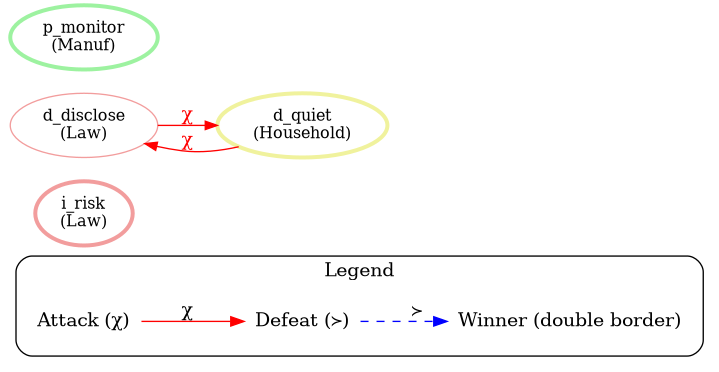


=== Winner (accepted heads) ===
['d_quiet', 'i_risk', 'p_monitor']
=== Attack relations (chi) present ===
  d_disclose  <->  d_quiet
  d_quiet  <->  d_disclose


In [ ]:
from IPython.display import Image, display

(pf, norms, cont, prio, cd, nd, contrd, pd, bp, mp) = load_scenario(PATH)
J = Jiminy(norms, cont, prio, cd, nd, contrd, pd, bp, mp)
args = J.generate_arguments(["w1", "w2"])
E, P, O = J.compute_jiminy(["w1", "w2"])
accepted = [a for a in args if a.hd in (E | P | O)]

av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in accepted},
               priorities=J.priorities, contrariness=J.contrariness)
name = "jair_authority_af"
av.render(name)
display(Image(filename=f"{name}.png"))

print()
print("=== Winner (accepted heads) ===")
print(sorted({a.hd for a in accepted}))
print("=== Attack relations (chi) present ===")
for src, contraries in J.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")
